# Lab 11: Using LSTM for Time Series Forecasting (Regression)

**Course:** COMP-341L - Artificial Neural Networks Lab  
**Student:** Zarmeena Jawad  
**Roll Number:** B23F0115AI125  
**Section:** B.S AI - Red  
**Execution Environment:** Google Colab

## Learning Objectives
- Understand time series data (trend, seasonality, noise)
- Convert a time series into a supervised learning problem (sliding window)
- Implement LSTM for regression forecasting
- Compare a baseline vs a modified LSTM configuration
- Forecast the next 12 time steps and analyze performance

## Lab Tasks (Summary)
1. Plot the time series and identify trend + seasonality  
2. Normalize data and create sequences (window size = 12)  
3. Train an LSTM regression model (15–20 epochs)  
4. Modify ANY TWO parameters and compare train/val loss  
5. Forecast the next 12 time steps and plot the forecast


In [1]:
import os
from datetime import datetime

try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

STUDENT_NAME = "Zarmeena Jawad"
STUDENT_ROLL = "B23F0115AI125"
STUDENT_SECTION = "B.S AI - Red"
STUDENT_FOLDER_NAME = "Zarmeena Jawad's Lab"
USE_GOOGLE_DRIVE = True

if IN_COLAB:
    if not USE_GOOGLE_DRIVE:
        raise RuntimeError("Set USE_GOOGLE_DRIVE=True to save everything on Google Drive.")

    # Requirement: everything saved on Google Drive
    drive.mount("/content/drive", force_remount=True)
    BASE_DIR = f"/content/drive/MyDrive/COMP-341L/Lab 11/{STUDENT_FOLDER_NAME}"
    print("Google Drive mounted successfully.")
else:
    BASE_DIR = os.environ.get("LAB11_BASE_DIR", ".")

PLOTS_DIR = os.path.join(BASE_DIR, "plots")

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

print("IN_COLAB :", IN_COLAB)
print("USE_GOOGLE_DRIVE:", USE_GOOGLE_DRIVE)
print("BASE_DIR :", os.path.abspath(BASE_DIR))
print("PLOTS_DIR:", os.path.abspath(PLOTS_DIR))


Mounted at /content/drive
Google Drive mounted successfully.
IN_COLAB : True
USE_GOOGLE_DRIVE: True
BASE_DIR : /content/drive/MyDrive/COMP-341L/Lab 11/Zarmeena Jawad's Lab
PLOTS_DIR: /content/drive/MyDrive/COMP-341L/Lab 11/Zarmeena Jawad's Lab/plots


## Task 1: Data Understanding (Trend + Seasonality)
We load a **univariate** time series (e.g., retail sales per month) and visualize:
- The raw series
- Rolling mean (trend)
- Seasonal pattern (average by month-of-year if dates exist)


In [2]:
import math
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# Dataset configuration
# -----------------------------
DATASET_LOCAL_NAME = "Sales Forecasting Dataset.csv"
DATE_COL = None   # e.g. "Date"
VALUE_COL = None  # e.g. "Sales"

# Baseline (Task 2/3)
BASE_WINDOW = 12
BASE_LSTM_UNITS = 50
BASE_DROPOUT = 0.0

# Modified model (Task 4) - modify ANY TWO:
MOD_WINDOW = 24
MOD_LSTM_UNITS = 100
MOD_DROPOUT = 0.0

EPOCHS = 20
BATCH_SIZE = 16
FORECAST_STEPS = 12


In [3]:
def _try_parse_datetime(series):
    parsed = pd.to_datetime(series, errors="coerce", infer_datetime_format=True)
    valid_ratio = float(parsed.notna().mean())
    if valid_ratio >= 0.8:
        return parsed
    return None


def _infer_date_col(df):
    for col in df.columns:
        parsed = _try_parse_datetime(df[col])
        if parsed is not None:
            return col
    return None


def _infer_value_col(df, date_col):
    preferred = ["sales", "value", "y", "target", "passengers", "count", "demand"]
    cols = [c for c in df.columns if c != date_col]
    lowered = {c: str(c).strip().lower() for c in cols}
    for want in preferred:
        for c in cols:
            if want == lowered[c]:
                return c

    numeric_cols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]
    if numeric_cols:
        return numeric_cols[0]

    for c in cols:
        coerced = pd.to_numeric(df[c], errors="coerce")
        if float(coerced.notna().mean()) >= 0.8:
            return c
    raise ValueError("Could not infer a numeric value column. Set VALUE_COL manually.")


FALLBACK_URLS = [
    ("monthly-car-sales.csv", "https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv"),
    ("airline-passengers.csv", "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"),
]


def locate_or_download_dataset():
    import shutil

    target_path = os.path.join(BASE_DIR, DATASET_LOCAL_NAME)
    candidates = [
        target_path,
        os.path.join(".", DATASET_LOCAL_NAME),
        "/content/" + DATASET_LOCAL_NAME,
        "/content/drive/MyDrive/" + DATASET_LOCAL_NAME,
        "/content/drive/MyDrive/Datasets/" + DATASET_LOCAL_NAME,
    ]
    for candidate in candidates:
        if os.path.exists(candidate):
            if os.path.abspath(candidate) != os.path.abspath(target_path):
                shutil.copy2(candidate, target_path)
                print(f"Copied dataset into Google Drive folder: {target_path}")
                return target_path, f"copied_from:{candidate}"
            return target_path, "local"

    print("Dataset not found locally in BASE_DIR. Downloading a small fallback time-series CSV...")
    last_error = None
    for filename, url in FALLBACK_URLS:
        try:
            df_remote = pd.read_csv(url)
            df_remote.to_csv(target_path, index=False)
            print(f"Downloaded fallback dataset from: {url}")
            print(f"Saved to: {target_path}")
            return target_path, f"downloaded:{filename}"
        except Exception as e:
            last_error = e
            continue

    raise RuntimeError(f"Could not download fallback dataset. Last error: {repr(last_error)}")


csv_path, dataset_source = locate_or_download_dataset()
print("Dataset path  :", csv_path)
print("Dataset source:", dataset_source)

raw_df = pd.read_csv(csv_path)
if raw_df.empty:
    raise ValueError("Loaded dataset is empty.")

detected_date_col = DATE_COL or _infer_date_col(raw_df)
detected_value_col = VALUE_COL or _infer_value_col(raw_df, detected_date_col)

df = raw_df.copy()
if detected_date_col is not None:
    df["_date"] = pd.to_datetime(df[detected_date_col], errors="coerce", infer_datetime_format=True)
    df = df.dropna(subset=["_date"]).copy()
    df = df.sort_values("_date").reset_index(drop=True)
else:
    df["_date"] = pd.RangeIndex(start=0, stop=len(df), step=1)

df["_value"] = pd.to_numeric(df[detected_value_col], errors="coerce")
df = df.dropna(subset=["_value"]).copy()
df = df.reset_index(drop=True)

print("Detected date column :", detected_date_col)
print("Detected value column:", detected_value_col)
print("Rows after cleaning  :", len(df))
df.head()


Dataset not found locally in BASE_DIR. Downloading a small fallback time-series CSV...
Downloaded fallback dataset from: https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv
Saved to: /content/drive/MyDrive/COMP-341L/Lab 11/Zarmeena Jawad's Lab/Sales Forecasting Dataset.csv
Dataset path  : /content/drive/MyDrive/COMP-341L/Lab 11/Zarmeena Jawad's Lab/Sales Forecasting Dataset.csv
Dataset source: downloaded:monthly-car-sales.csv
Detected date column : Month
Detected value column: Sales
Rows after cleaning  : 108


,Month,Sales,_date,_value
0,1960-01,6550,1960-01-01,6550
1,1960-02,8728,1960-02-01,8728
2,1960-03,12026,1960-03-01,12026
3,1960-04,14395,1960-04-01,14395
4,1960-05,14587,1960-05-01,14587


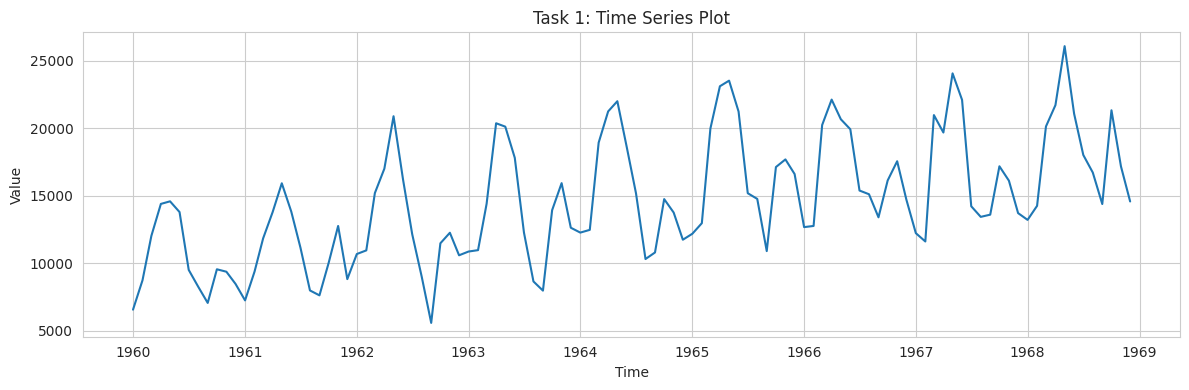

Saved: /content/drive/MyDrive/COMP-341L/Lab 11/Zarmeena Jawad's Lab/plots/task1_time_series.png


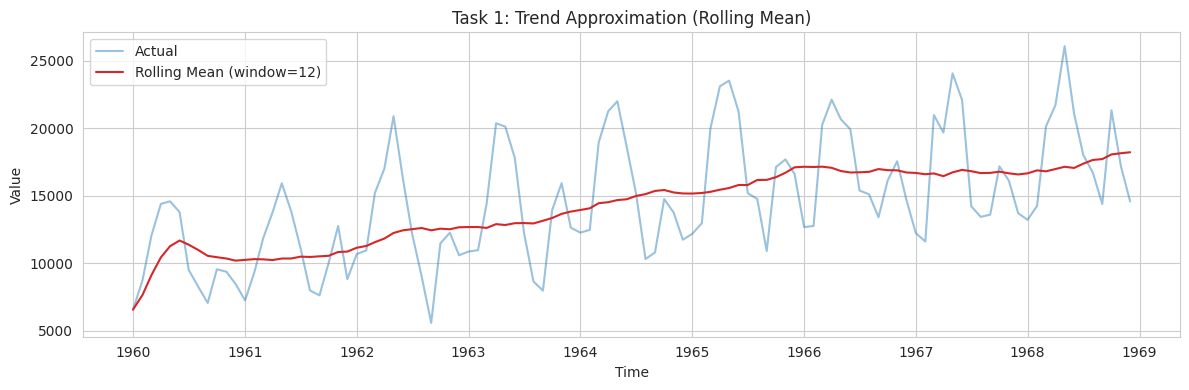

Saved: /content/drive/MyDrive/COMP-341L/Lab 11/Zarmeena Jawad's Lab/plots/task1_trend_rolling_mean.png


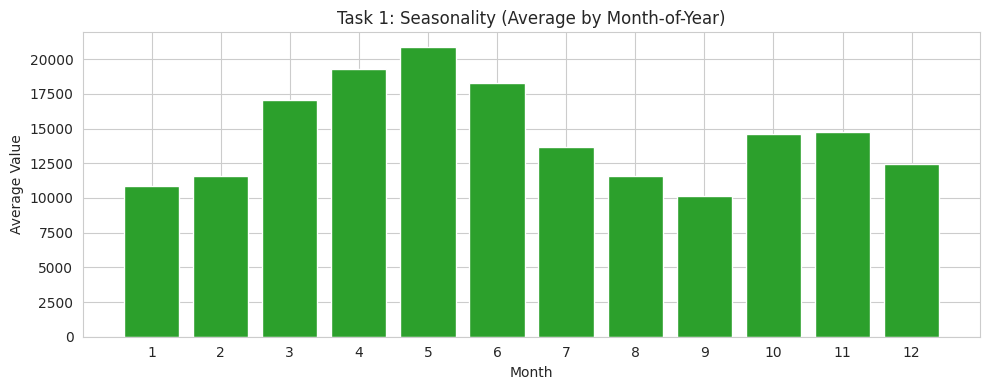

Saved: /content/drive/MyDrive/COMP-341L/Lab 11/Zarmeena Jawad's Lab/plots/task1_seasonality_month_avg.png


In [4]:
plt.figure(figsize=(12, 4))
plt.plot(df["_date"], df["_value"], color="#1f77b4")
plt.title("Task 1: Time Series Plot")
plt.xlabel("Time")
plt.ylabel("Value")
plt.tight_layout()
path = os.path.join(PLOTS_DIR, "task1_time_series.png")
plt.savefig(path, dpi=140, bbox_inches="tight")
plt.show()
print("Saved:", path)

rolling_window = 12 if len(df) >= 24 else max(3, len(df) // 10)
trend = df["_value"].rolling(window=rolling_window, min_periods=1).mean()
plt.figure(figsize=(12, 4))
plt.plot(df["_date"], df["_value"], alpha=0.45, label="Actual")
plt.plot(df["_date"], trend, color="#d62728", label=f"Rolling Mean (window={rolling_window})")
plt.title("Task 1: Trend Approximation (Rolling Mean)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
path = os.path.join(PLOTS_DIR, "task1_trend_rolling_mean.png")
plt.savefig(path, dpi=140, bbox_inches="tight")
plt.show()
print("Saved:", path)

if detected_date_col is not None and pd.api.types.is_datetime64_any_dtype(df["_date"]):
    df["_month"] = pd.to_datetime(df["_date"]).dt.month
    month_avg = df.groupby("_month")["_value"].mean().reindex(range(1, 13))
    plt.figure(figsize=(10, 4))
    plt.bar(month_avg.index, month_avg.values, color="#2ca02c")
    plt.title("Task 1: Seasonality (Average by Month-of-Year)")
    plt.xlabel("Month")
    plt.ylabel("Average Value")
    plt.xticks(range(1, 13))
    plt.tight_layout()
    path = os.path.join(PLOTS_DIR, "task1_seasonality_month_avg.png")
    plt.savefig(path, dpi=140, bbox_inches="tight")
    plt.show()
    print("Saved:", path)
else:
    print("Seasonality plot skipped (no valid datetime column detected).")


## Task 2: Preprocessing
- Normalize values using `MinMaxScaler`
- Create sequences using sliding window
- Train/Val/Test split by time


In [5]:
values = df["_value"].astype("float32").to_numpy().reshape(-1, 1)
dates = df["_date"].to_numpy()

n = len(values)
train_end = int(0.70 * n)
val_end = int(0.85 * n)

scaler = MinMaxScaler()
scaler.fit(values[:train_end])
values_scaled = scaler.transform(values).astype("float32")


def make_windowed_dataset(values_scaled: np.ndarray, start: int, end: int, window: int):
    X, y, y_idx = [], [], []
    for i in range(start + window, end):
        X.append(values_scaled[i - window : i, 0])
        y.append(values_scaled[i, 0])
        y_idx.append(i)
    X = np.array(X, dtype="float32").reshape(-1, window, 1)
    y = np.array(y, dtype="float32").reshape(-1, 1)
    y_idx = np.array(y_idx, dtype="int32")
    return X, y, y_idx


def split_sets(window: int):
    X_train, y_train, idx_train = make_windowed_dataset(values_scaled, 0, train_end, window)
    X_val, y_val, idx_val = make_windowed_dataset(values_scaled, train_end - window, val_end, window)
    X_test, y_test, idx_test = make_windowed_dataset(values_scaled, val_end - window, n, window)
    return (X_train, y_train, idx_train), (X_val, y_val, idx_val), (X_test, y_test, idx_test)


(X_train_b, y_train_b, idx_train_b), (X_val_b, y_val_b, idx_val_b), (X_test_b, y_test_b, idx_test_b) = split_sets(BASE_WINDOW)

print("Baseline window:", BASE_WINDOW)
print("Train:", X_train_b.shape, y_train_b.shape)
print("Val  :", X_val_b.shape, y_val_b.shape)
print("Test :", X_test_b.shape, y_test_b.shape)


Baseline window: 12
Train: (63, 12, 1) (63, 1)
Val  : (16, 12, 1) (16, 1)
Test : (17, 12, 1) (17, 1)


## Task 3: Baseline LSTM (Regression)


In [6]:
def build_lstm_regressor(window: int, units: int, dropout: float = 0.0):
    model = Sequential()
    model.add(LSTM(units, input_shape=(window, 1)))
    if dropout and dropout > 0:
        model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer="adam", loss="mse")
    return model


base_model = build_lstm_regressor(BASE_WINDOW, BASE_LSTM_UNITS, BASE_DROPOUT)
base_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 496ms/step - loss: 0.2531 - val_loss: 0.3283
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1563 - val_loss: 0.1783
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0885 - val_loss: 0.0785
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0582 - val_loss: 0.0517
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0654 - val_loss: 0.0600
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0658 - val_loss: 0.0522
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0566 - val_loss: 0.0537
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0542 - val_loss: 0.0620
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0556 - val_loss: 0.0662
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0560 - val_loss: 0.0643
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0549 - val_loss: 0.0591
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0537 - val_loss: 0.0545


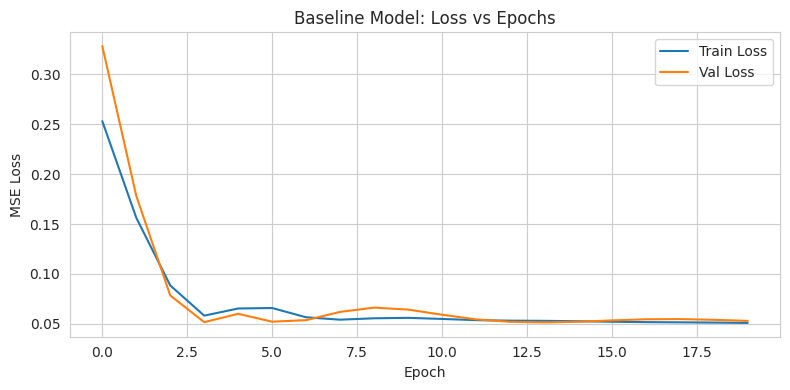

Saved: /content/drive/MyDrive/COMP-341L/Lab 11/Zarmeena Jawad's Lab/plots/task3_baseline_loss.png


In [7]:
base_history = base_model.fit(
    X_train_b,
    y_train_b,
    validation_data=(X_val_b, y_val_b),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)

plt.figure(figsize=(8, 4))
plt.plot(base_history.history["loss"], label="Train Loss")
plt.plot(base_history.history["val_loss"], label="Val Loss")
plt.title("Baseline Model: Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
path = os.path.join(PLOTS_DIR, "task3_baseline_loss.png")
plt.savefig(path, dpi=140, bbox_inches="tight")
plt.show()
print("Saved:", path)


Baseline MAE : 2937.7480
Baseline RMSE: 3788.9169


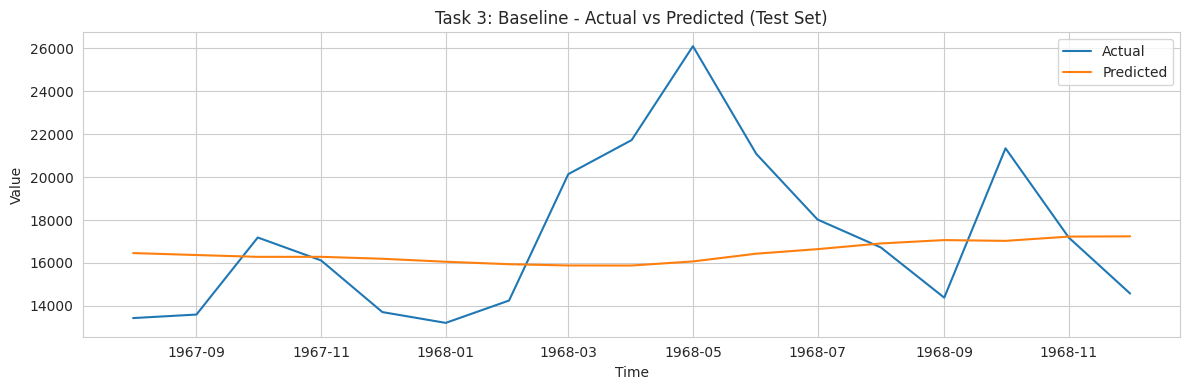

Saved: /content/drive/MyDrive/COMP-341L/Lab 11/Zarmeena Jawad's Lab/plots/task3_baseline_actual_vs_pred.png


In [8]:
base_pred_scaled = base_model.predict(X_test_b, verbose=0)
base_pred = scaler.inverse_transform(base_pred_scaled)
y_test = scaler.inverse_transform(y_test_b)

base_mae = mean_absolute_error(y_test, base_pred)
base_rmse = math.sqrt(mean_squared_error(y_test, base_pred))

print(f"Baseline MAE : {base_mae:.4f}")
print(f"Baseline RMSE: {base_rmse:.4f}")

test_dates = dates[idx_test_b]
plt.figure(figsize=(12, 4))
plt.plot(test_dates, y_test, label="Actual", color="#1f77b4")
plt.plot(test_dates, base_pred, label="Predicted", color="#ff7f0e")
plt.title("Task 3: Baseline - Actual vs Predicted (Test Set)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
path = os.path.join(PLOTS_DIR, "task3_baseline_actual_vs_pred.png")
plt.savefig(path, dpi=140, bbox_inches="tight")
plt.show()
print("Saved:", path)


## Task 4: Modified Model (ANY TWO changes)


In [9]:
(X_train_m, y_train_m, idx_train_m), (X_val_m, y_val_m, idx_val_m), (X_test_m, y_test_m, idx_test_m) = split_sets(MOD_WINDOW)

mod_model = build_lstm_regressor(MOD_WINDOW, MOD_LSTM_UNITS, MOD_DROPOUT)
mod_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - loss: 0.3670 - val_loss: 0.3404
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1794 - val_loss: 0.0986
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0704 - val_loss: 0.0822
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0748 - val_loss: 0.0511
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0604 - val_loss: 0.0722
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0698 - val_loss: 0.0820
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0712 - val_loss: 0.0720
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0651 - val_loss: 0.0579
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0600 - val_loss: 0.0516
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0589 - val_loss: 0.0511
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0583 - val_loss: 0.0539
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0586 - val_loss: 0.0582


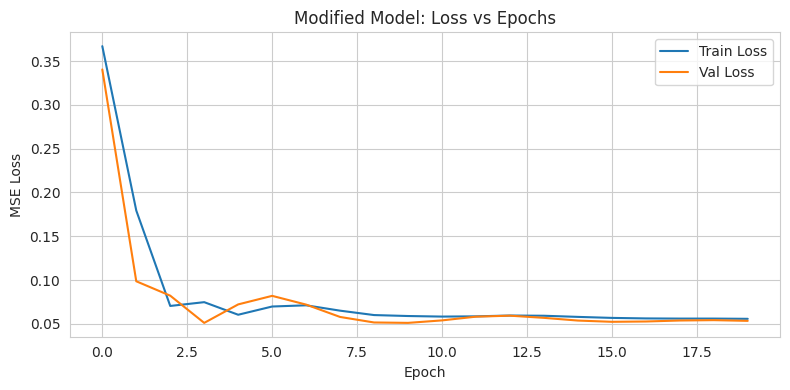

Saved: /content/drive/MyDrive/COMP-341L/Lab 11/Zarmeena Jawad's Lab/plots/task4_modified_loss.png


In [10]:
mod_history = mod_model.fit(
    X_train_m,
    y_train_m,
    validation_data=(X_val_m, y_val_m),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)

plt.figure(figsize=(8, 4))
plt.plot(mod_history.history["loss"], label="Train Loss")
plt.plot(mod_history.history["val_loss"], label="Val Loss")
plt.title("Modified Model: Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
path = os.path.join(PLOTS_DIR, "task4_modified_loss.png")
plt.savefig(path, dpi=140, bbox_inches="tight")
plt.show()
print("Saved:", path)


Modified MAE : 2916.6133
Modified RMSE: 3805.1677


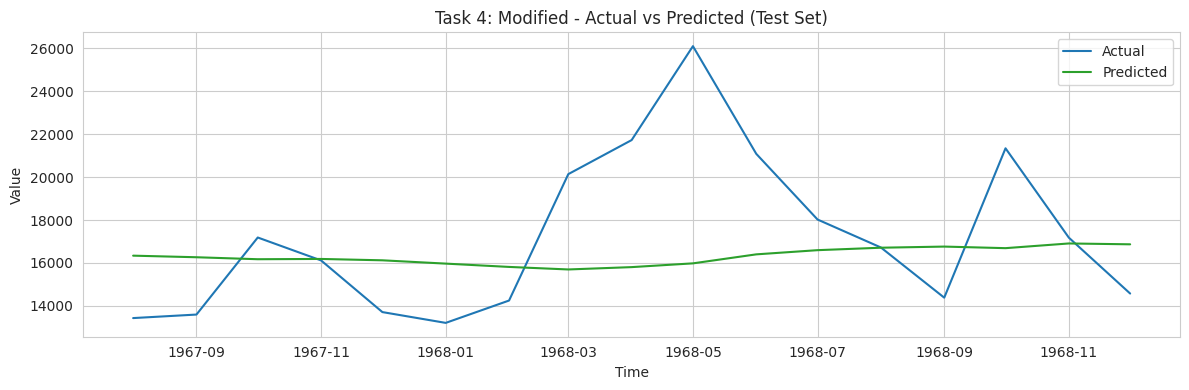

Saved: /content/drive/MyDrive/COMP-341L/Lab 11/Zarmeena Jawad's Lab/plots/task4_modified_actual_vs_pred.png


In [11]:
mod_pred_scaled = mod_model.predict(X_test_m, verbose=0)
mod_pred = scaler.inverse_transform(mod_pred_scaled)
y_test_m_inv = scaler.inverse_transform(y_test_m)

mod_mae = mean_absolute_error(y_test_m_inv, mod_pred)
mod_rmse = math.sqrt(mean_squared_error(y_test_m_inv, mod_pred))

print(f"Modified MAE : {mod_mae:.4f}")
print(f"Modified RMSE: {mod_rmse:.4f}")

test_dates_m = dates[idx_test_m]
plt.figure(figsize=(12, 4))
plt.plot(test_dates_m, y_test_m_inv, label="Actual", color="#1f77b4")
plt.plot(test_dates_m, mod_pred, label="Predicted", color="#2ca02c")
plt.title("Task 4: Modified - Actual vs Predicted (Test Set)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
path = os.path.join(PLOTS_DIR, "task4_modified_actual_vs_pred.png")
plt.savefig(path, dpi=140, bbox_inches="tight")
plt.show()
print("Saved:", path)


In [12]:
comparison_df = pd.DataFrame(
    [
        {
            "Model": "Base",
            "Window": BASE_WINDOW,
            "LSTM Units": BASE_LSTM_UNITS,
            "Dropout": BASE_DROPOUT,
            "Train Loss (final)": float(base_history.history["loss"][-1]),
            "Val Loss (final)": float(base_history.history["val_loss"][-1]),
        },
        {
            "Model": "Modified",
            "Window": MOD_WINDOW,
            "LSTM Units": MOD_LSTM_UNITS,
            "Dropout": MOD_DROPOUT,
            "Train Loss (final)": float(mod_history.history["loss"][-1]),
            "Val Loss (final)": float(mod_history.history["val_loss"][-1]),
        },
    ]
)

comparison_df


,Model,Window,LSTM Units,Dropout,Train Loss (final),Val Loss (final)
0,Base,12,50,0.0,0.050946,0.052949
1,Modified,24,100,0.0,0.055747,0.053419


## Task 5: Forecast the Next 12 Steps


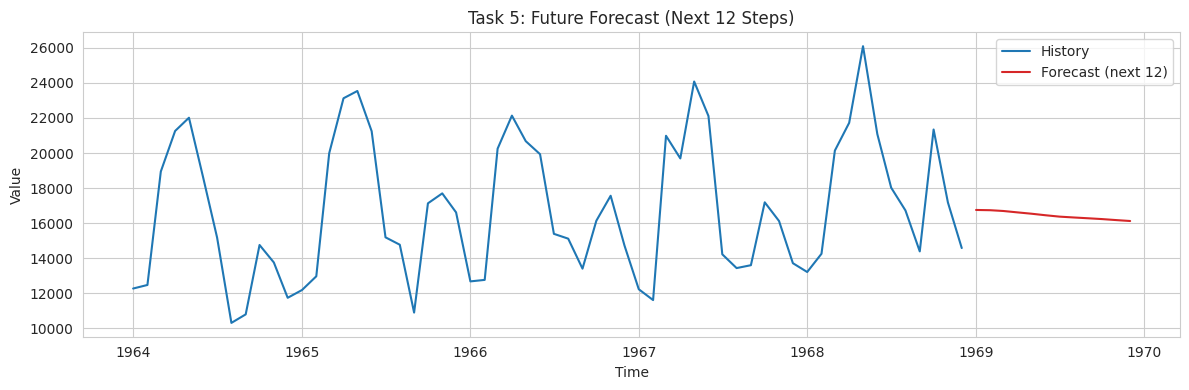

Saved: /content/drive/MyDrive/COMP-341L/Lab 11/Zarmeena Jawad's Lab/plots/task5_future_forecast.png


In [13]:
history_scaled = values_scaled[:, 0].astype("float32").tolist()
window = MOD_WINDOW

future_scaled = []
for _ in range(FORECAST_STEPS):
    x_input = np.array(history_scaled[-window:], dtype="float32").reshape(1, window, 1)
    yhat = float(mod_model.predict(x_input, verbose=0)[0, 0])
    future_scaled.append(yhat)
    history_scaled.append(yhat)

future = scaler.inverse_transform(np.array(future_scaled, dtype="float32").reshape(-1, 1))[:, 0]

if detected_date_col is not None and pd.api.types.is_datetime64_any_dtype(df["_date"]) and len(df) >= 2:
    dt = pd.to_datetime(df["_date"])
    freq = pd.infer_freq(dt)
    if freq:
        future_dates = pd.date_range(dt.iloc[-1], periods=FORECAST_STEPS + 1, freq=freq)[1:]
    else:
        step = dt.iloc[-1] - dt.iloc[-2]
        future_dates = [dt.iloc[-1] + (i + 1) * step for i in range(FORECAST_STEPS)]
else:
    last = len(df) - 1
    future_dates = list(range(last + 1, last + 1 + FORECAST_STEPS))

lookback = min(60, len(df))
plt.figure(figsize=(12, 4))
plt.plot(df["_date"].iloc[-lookback:], df["_value"].iloc[-lookback:], label="History", color="#1f77b4")
plt.plot(future_dates, future, label="Forecast (next 12)", color="#d62728")
plt.title("Task 5: Future Forecast (Next 12 Steps)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
path = os.path.join(PLOTS_DIR, "task5_future_forecast.png")
plt.savefig(path, dpi=140, bbox_inches="tight")
plt.show()
print("Saved:", path)


In [14]:
        report_md = f"""# Lab 11: LSTM for Time Series Forecasting (Regression)

**Student:** {STUDENT_NAME}  
**Roll Number:** {STUDENT_ROLL}  
**Section:** {STUDENT_SECTION}  
**Date:** {datetime.now().strftime('%B %d, %Y')}

## Dataset
- Detected date column: `{detected_date_col}`
- Detected value column: `{detected_value_col}`
- Samples (after cleaning): `{len(df)}`

## Baseline vs Modified (final losses)
{comparison_df.to_markdown(index=False)}

## Plots
- `plots/task1_time_series.png`
- `plots/task1_trend_rolling_mean.png`
- `plots/task3_baseline_loss.png`
- `plots/task3_baseline_actual_vs_pred.png`
- `plots/task4_modified_loss.png`
- `plots/task4_modified_actual_vs_pred.png`
- `plots/task5_future_forecast.png`
"""

        html = f"""<!doctype html>
<html>
  <head>
    <meta charset='utf-8'>
    <title>Lab 11 Report - {STUDENT_NAME}</title>
    <style>
      body {{ font-family: Arial, sans-serif; margin: 24px; line-height: 1.45; }}
      img {{ max-width: 100%; border: 1px solid #ddd; border-radius: 10px; padding: 6px; }}
      table {{ border-collapse: collapse; width: 100%; }}
      th, td {{ border: 1px solid #ddd; padding: 8px; text-align: left; }}
      th {{ background: #f2f2f2; }}
    </style>
  </head>
  <body>
    <h1>Lab 11: LSTM for Time Series Forecasting (Regression)</h1>
    <p><strong>Student:</strong> {STUDENT_NAME} &nbsp; | &nbsp; <strong>Roll:</strong> {STUDENT_ROLL} &nbsp; | &nbsp; <strong>Section:</strong> {STUDENT_SECTION}</p>
    <p><strong>Date:</strong> {datetime.now().strftime('%B %d, %Y')}</p>
    <h2>Loss Comparison (final epoch)</h2>
    {comparison_df.to_html(index=False)}
    <h2>Forecast</h2>
    <img src='plots/task5_future_forecast.png' alt='Future forecast'>
  </body>
</html>
"""

        md_path = os.path.join(BASE_DIR, "Lab_Report_11.md")
        html_path = os.path.join(BASE_DIR, "Lab_Report_11.html")

        with open(md_path, "w", encoding="utf-8") as f:
            f.write(report_md)
        with open(html_path, "w", encoding="utf-8") as f:
            f.write(html)

        print("Saved:", os.path.abspath(md_path))
        print("Saved:", os.path.abspath(html_path))


Saved: /content/drive/MyDrive/COMP-341L/Lab 11/Zarmeena Jawad's Lab/Lab_Report_11.md
Saved: /content/drive/MyDrive/COMP-341L/Lab 11/Zarmeena Jawad's Lab/Lab_Report_11.html
